# EDA for Unbalanced Diabetes Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 23)
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2023.csv")
df.loc[df['KidneyDisease'] == 2, 'KidneyDisease'] = 0
df.loc[df['Asthma'] == 2, 'Asthma'] = 0
df.loc[df['COPD'] == 2, 'COPD'] = 0


## Initial Status of Dataset

In [2]:
df.shape

(261589, 23)

In [3]:
df.columns

Index(['Diabetes_binary', 'KidneyDisease', 'HighBP', 'HighChol', 'CholCheck',
       'Asthma', 'COPD', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
       'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'AgeGroup',
       'Education', 'Income'],
      dtype='object')

In [4]:
df.dtypes

Diabetes_binary         float64
KidneyDisease           float64
HighBP                  float64
HighChol                float64
CholCheck               float64
Asthma                  float64
COPD                    float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
AgeGroup                float64
Education               float64
Income                  float64
dtype: object

In [5]:
df.describe()

,Diabetes_binary,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
count,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000,261589.000000
mean,0.146206,0.067438,0.430435,0.420843,0.965671,0.164063,0.092840,28.824117,0.396465,0.042104,0.088830,0.776875,0.063153,0.963194,0.073164,2.575911,4.178471,4.400892,0.152801,0.483465,7.993096,5.165366,7.192118
std,0.353314,0.416936,0.495138,0.493695,0.182072,0.476339,0.429776,6.523703,0.489164,0.200827,0.284499,0.416342,0.243238,0.188285,0.260407,1.029234,8.055756,8.699962,0.359796,0.499727,3.332893,0.945057,2.383834
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,6.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,32.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,4.000000,4.000000,0.000000,1.000000,11.000000,6.000000,9.000000
max,1.000000,9.000000,1.000000,1.000000,1.000000,9.000000,9.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,11.000000


In [6]:
df.head(20)

,Diabetes_binary,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,22.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,4.0,2.0,6.0,1.0,0.0,13.0,4.0,2.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,12.0,5.0,7.0
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,30.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,3.0,2.0,0.0,0.0,9.0,5.0,7.0
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,33.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,5.0,1.0,0.0,13.0,5.0,6.0
4,1.0,0.0,1.0,1.0,1.0,0.0,0.0,23.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,4.0,7.0
5,0.0,0.0,1.0,1.0,1.0,0.0,0.0,42.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,8.0,5.0,7.0
6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,30.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,10.0,6.0,9.0
7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,24.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,5.0,9.0
8,0.0,0.0,1.0,0.0,1.0,0.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,12.0,5.0,9.0
9,0.0,0.0,1.0,0.0,1.0,0.0,0.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,4.0,1.0,0.0,13.0,4.0,3.0


In [7]:
df.isna().sum()

Diabetes_binary         0
KidneyDisease           0
HighBP                  0
HighChol                0
CholCheck               0
Asthma                  0
COPD                    0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
AgeGroup                0
Education               0
Income                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(18588)

## Removing the Unknown Values from dataset


Removing the rows that contains meaningless data

In our dataset some of the features are binary labeled (like kidneyDisease,HighBP,Asthma,Sex, etc.). If this features takes some other value than 0 or 1, it means the feature is not known for that datapoint (for majority of the binary features value 7 means don't know and value 9 means the question about this feature is refused to be answered). 

Since it may create conflict and the number of rows with missing data is very small compared to the rest, the best option is dropping them from our dataset.

### FEATURES      -      VALID VALUES

Diabetes_binary    -     [0 , 1]

KidneyDisease     -      [0 , 1]

HighBP         -         [0 , 1]

HighChol       -         [0 , 1]

CholCheck      -        [0 , 1]

Asthma         -         [0 , 1]




In [9]:
(~df['Diabetes_binary'].isin([0.0,1.0])).sum()

np.int64(0)

In [10]:
(~df['KidneyDisease'].isin([0.0,1.0])).sum()

np.int64(681)

In [11]:
df = df[df['KidneyDisease'].isin([0.0,1.0])].reset_index(drop=True)
(~df['KidneyDisease'].isin([0.0,1.0])).sum()

np.int64(0)

In [12]:
(~df['HighBP'].isin([0.0,1.0])).sum()

np.int64(0)

In [13]:
(~df['HighChol'].isin([0.0,1.0])).sum()

np.int64(0)

In [14]:
(~df['CholCheck'].isin([0.0,1.0])).sum()

np.int64(0)

In [15]:
(~df['Asthma'].isin([0.0,1.0])).sum()

np.int64(549)

In [16]:
df = df[df['Asthma'].isin([0.0,1.0])].reset_index(drop=True)
(~df['Asthma'].isin([0.0,1.0])).sum()

np.int64(0)

### FEATURES      -      VALID VALUES

COPD           -         [0 , 1]

BMI            -        [0 , 1]

Smoker         -         [0 , 1]

Stroke          -        [0 , 1]

HeartDiseaseorAttack        -    [0 , 1]

PhysActivity      -      [0 , 1]

HvyAlcoholConsump     -     [0 , 1]


In [17]:
(~df['COPD'].isin([0.0,1.0])).sum()

np.int64(570)

In [18]:
df = df[df['COPD'].isin([0.0,1.0])].reset_index(drop=True)
(~df['COPD'].isin([0.0,1.0])).sum()

np.int64(0)

In [19]:
(df['BMI'] <= 0 ).sum()

np.int64(0)

In [20]:
(~df['Smoker'].isin([0.0,1.0])).sum()

np.int64(0)

In [21]:
(~df['Stroke'].isin([0.0,1.0])).sum()

np.int64(0)

In [22]:
(~df['HeartDiseaseorAttack'].isin([0.0,1.0])).sum()

np.int64(0)

In [23]:
(~df['PhysActivity'].isin([0.0,1.0])).sum()

np.int64(0)

In [24]:
(~df['HvyAlcoholConsump'].isin([0.0,1.0])).sum()

np.int64(0)

### FEATURES      -      VALID VALUES

AnyHealthcare       -    [0 , 1]

NoDocbcCost        -     [0 , 1]

GenHlth          -       [0 , 5]

MentHlth         -       [0 , 31]

PhysHlth         -       [0 : 31]

In [25]:
(~df['AnyHealthcare'].isin([0.0,1.0])).sum()

np.int64(0)

In [26]:
(~df['NoDocbcCost'].isin([0.0,1.0])).sum()

np.int64(0)

In [27]:
(~df['GenHlth'].isin([1.0,2.0,3.0,4.0,5.0])).sum()

np.int64(0)

In [28]:
(df['MentHlth'] > 31).sum()

np.int64(0)

In [29]:
(df['PhysHlth'] > 31).sum()

np.int64(0)

### FEATURES      -      VALID VALUES

DiffWalk         -       [0 , 1]

Sex              -       [0 , 1]

AgeGroup         -       [0 , 13]

Education        -       [0 , 6]

Income           -       [0 : 11]

In [30]:
(~df['DiffWalk'].isin([0.0,1.0])).sum()

np.int64(0)

In [31]:
(~df['Sex'].isin([0.0,1.0])).sum()

np.int64(0)

In [32]:
(~df['AgeGroup'].isin(list(range(1,14)))).sum()

np.int64(0)

In [33]:
(~df['Education'].isin(list(range(1,7)))).sum()

np.int64(0)

In [34]:
(~df['Income'].isin(list(range(1,12)))).sum()

np.int64(0)

### Status of Dataset After Removal 

In [36]:
df.shape

(259789, 23)

In [37]:
df.describe()

,Diabetes_binary,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
count,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000,259789.000000
mean,0.145568,0.049117,0.429395,0.420156,0.965626,0.148932,0.075858,28.815523,0.395763,0.041849,0.088214,0.777785,0.063209,0.963274,0.072824,2.571903,4.163244,4.372506,0.151569,0.483442,7.987582,5.166943,7.199420
std,0.352673,0.216112,0.494991,0.493585,0.182188,0.356023,0.264771,6.511993,0.489015,0.200245,0.283606,0.415736,0.243339,0.188089,0.259849,1.027697,8.038675,8.671462,0.358603,0.499727,3.331620,0.944520,2.381881
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,6.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,32.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,4.000000,4.000000,0.000000,1.000000,11.000000,6.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,11.000000


## Visualizing The DataSet 

### Visualization for Nominal Columns

Text(0, 0.5, 'Frequency')

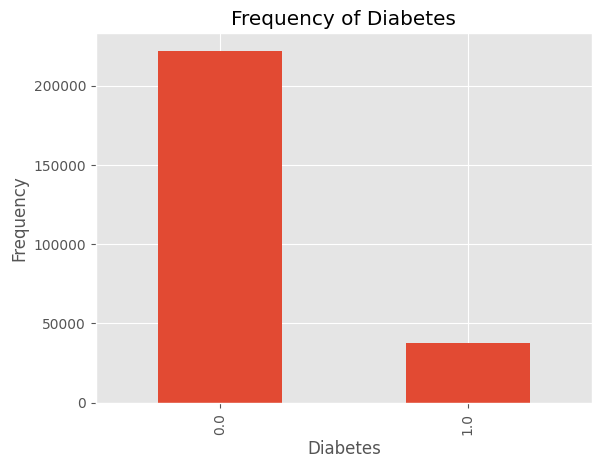

In [38]:
Diabetes_binary_ax = df['Diabetes_binary'].value_counts().plot(kind='bar', title='Frequency of Diabetes')

Diabetes_binary_ax.set_xlabel('Diabetes')
Diabetes_binary_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

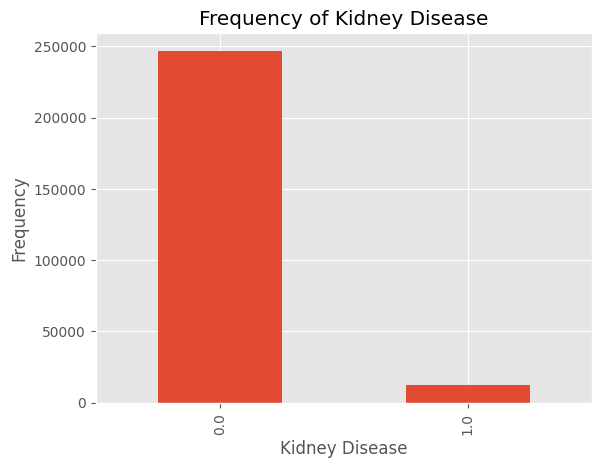

In [39]:
Kidney_disease_ax = df['KidneyDisease'].value_counts().plot(kind='bar', title='Frequency of Kidney Disease')

Kidney_disease_ax.set_xlabel('Kidney Disease')
Kidney_disease_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

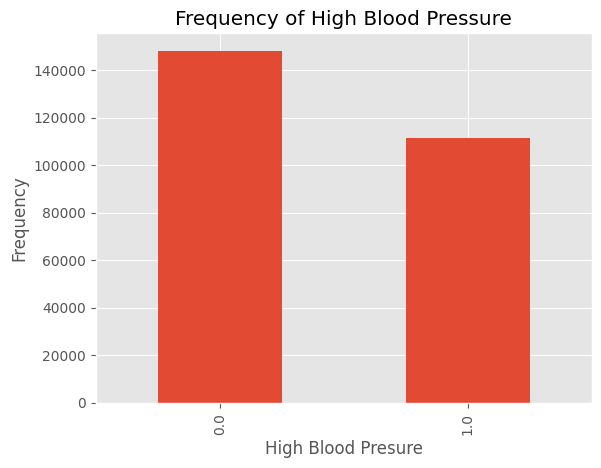

In [40]:
HighBP_ax = df['HighBP'].value_counts().plot(kind='bar', title='Frequency of High Blood Pressure')

HighBP_ax.set_xlabel('High Blood Presure')
HighBP_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

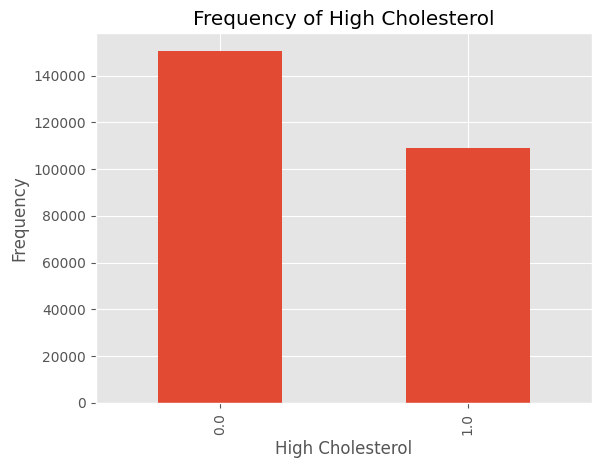

In [41]:
HighChol_ax = df['HighChol'].value_counts().plot(kind='bar', title='Frequency of High Cholesterol')

HighChol_ax.set_xlabel('High Cholesterol')
HighChol_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

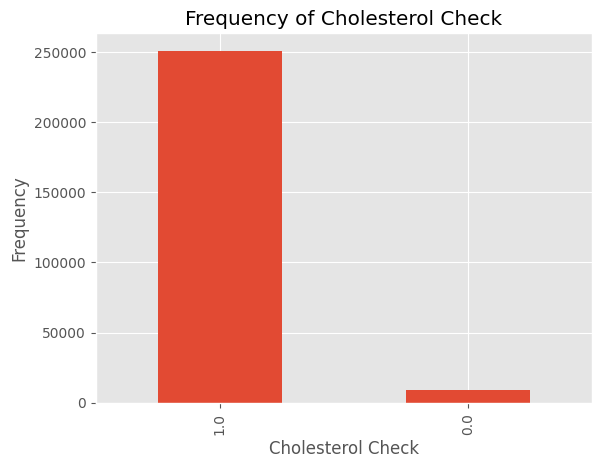

In [42]:
CholCheck_ax = df['CholCheck'].value_counts().plot(kind='bar', title='Frequency of Cholesterol Check')

CholCheck_ax.set_xlabel('Cholesterol Check')
CholCheck_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

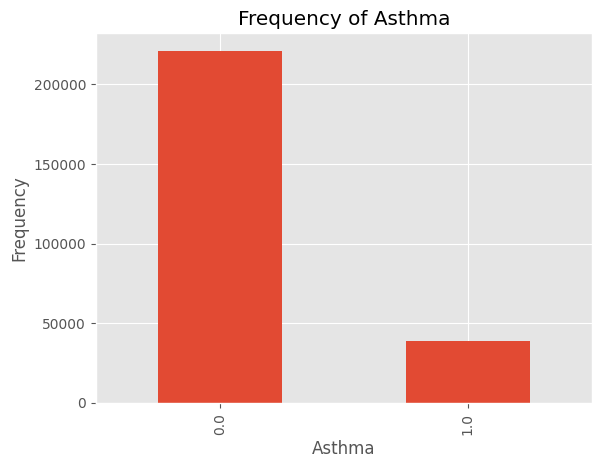

In [43]:
Asthma_ax = df['Asthma'].value_counts().plot(kind='bar', title='Frequency of Asthma')

Asthma_ax.set_xlabel('Asthma')
Asthma_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

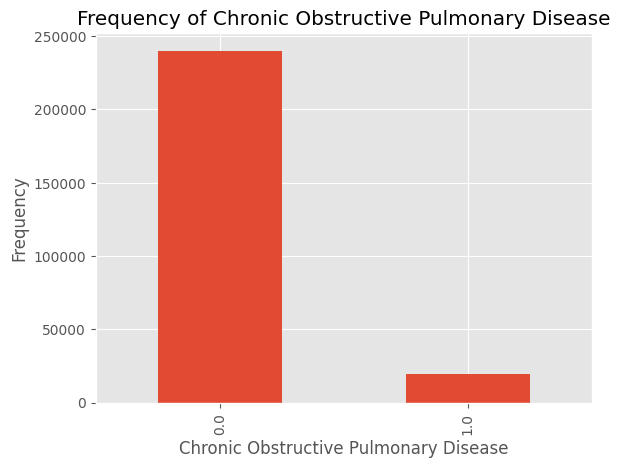

In [44]:
COPD_ax = df['COPD'].value_counts().plot(kind='bar', title='Frequency of Chronic Obstructive Pulmonary Disease')

COPD_ax.set_xlabel('Chronic Obstructive Pulmonary Disease')
COPD_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

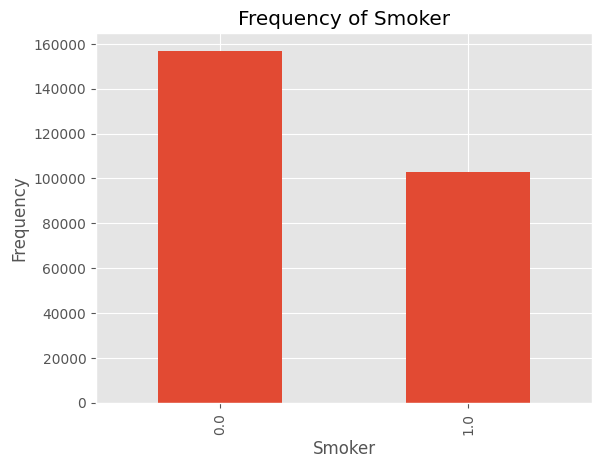

In [45]:
Smoker_ax = df['Smoker'].value_counts().plot(kind='bar', title='Frequency of Smoker')

Smoker_ax.set_xlabel('Smoker')
Smoker_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

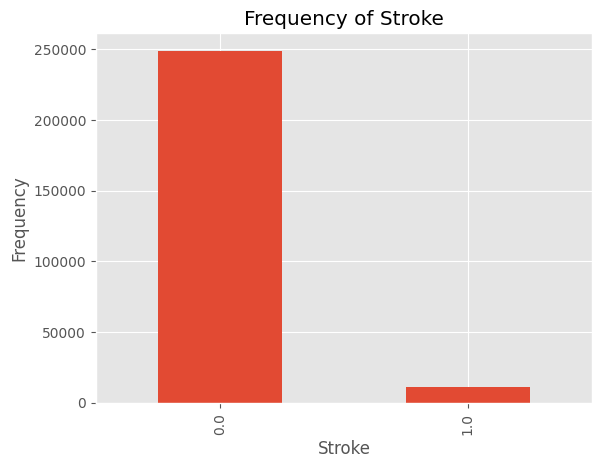

In [46]:
Stroke_ax = df['Stroke'].value_counts().plot(kind='bar', title='Frequency of Stroke')

Stroke_ax.set_xlabel('Stroke')
Stroke_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

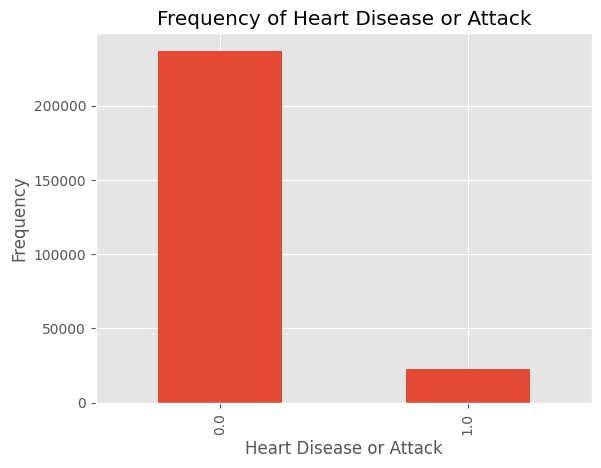

In [47]:
HeartDiseaseorAttack_ax = df['HeartDiseaseorAttack'].value_counts().plot(kind='bar', title='Frequency of Heart Disease or Attack')

HeartDiseaseorAttack_ax.set_xlabel('Heart Disease or Attack')
HeartDiseaseorAttack_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

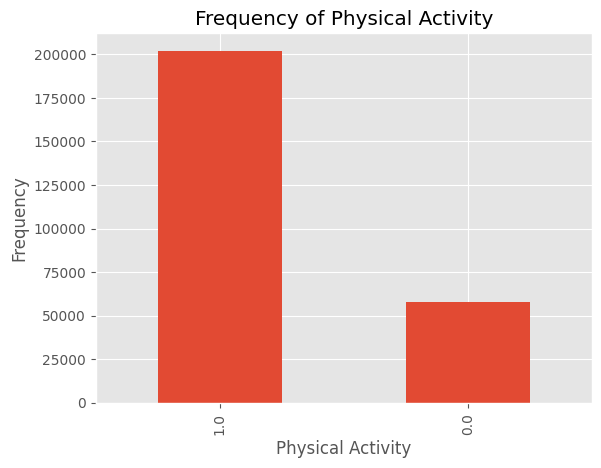

In [48]:
PhysActivity_ax = df['PhysActivity'].value_counts().plot(kind='bar', title='Frequency of Physical Activity')

PhysActivity_ax.set_xlabel('Physical Activity')
PhysActivity_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

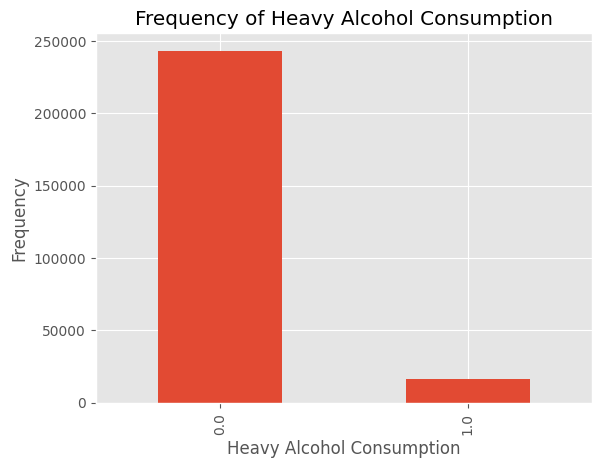

In [49]:
HvyAlcoholConsump_ax = df['HvyAlcoholConsump'].value_counts().plot(kind='bar', title='Frequency of Heavy Alcohol Consumption')

HvyAlcoholConsump_ax.set_xlabel('Heavy Alcohol Consumption')
HvyAlcoholConsump_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

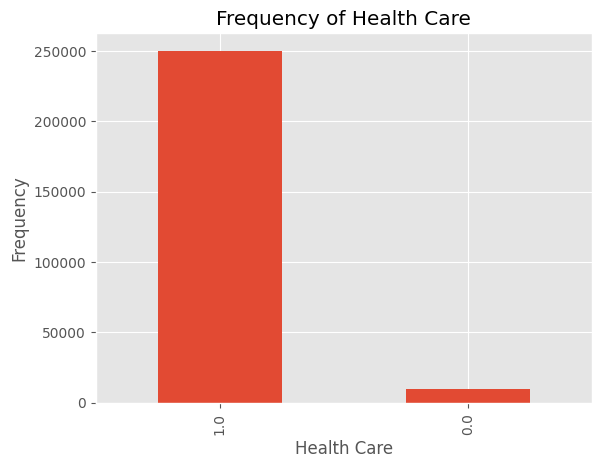

In [50]:
AnyHealthcare_ax = df['AnyHealthcare'].value_counts().plot(kind='bar', title='Frequency of Health Care')

AnyHealthcare_ax.set_xlabel('Health Care')
AnyHealthcare_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

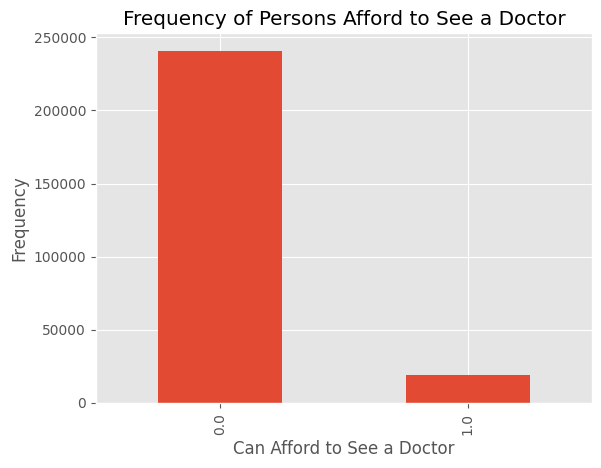

In [51]:
NoDocbcCost_ax = df['NoDocbcCost'].value_counts().plot(kind='bar', title='Frequency of Persons Afford to See a Doctor')

NoDocbcCost_ax.set_xlabel('Can Afford to See a Doctor')
NoDocbcCost_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

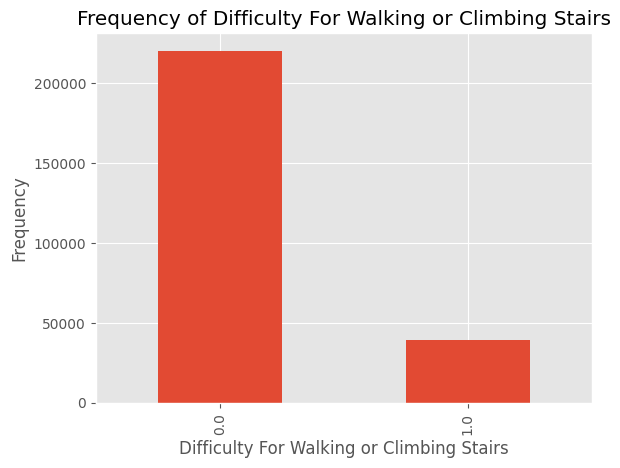

In [52]:
DiffWalk_ax = df['DiffWalk'].value_counts().plot(kind='bar', title='Frequency of Difficulty For Walking or Climbing Stairs')

DiffWalk_ax.set_xlabel('Difficulty For Walking or Climbing Stairs')
DiffWalk_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

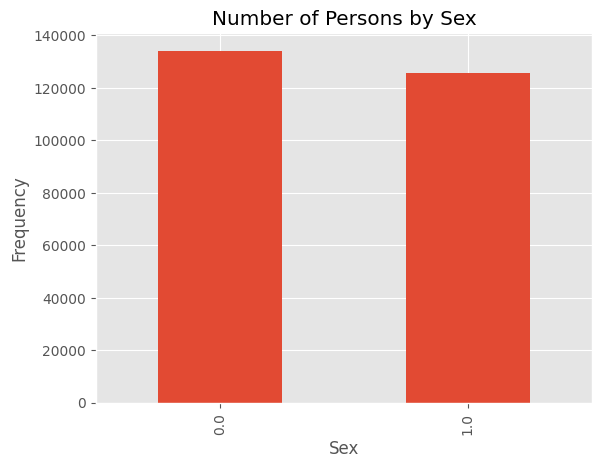

In [53]:
Sex_ax = df['Sex'].value_counts().plot(kind='bar', title='Number of Persons by Sex')

Sex_ax.set_xlabel('Sex')
Sex_ax.set_ylabel('Frequency')

### Visualization for Ordinal Features

Text(0, 0.5, 'Frequency')

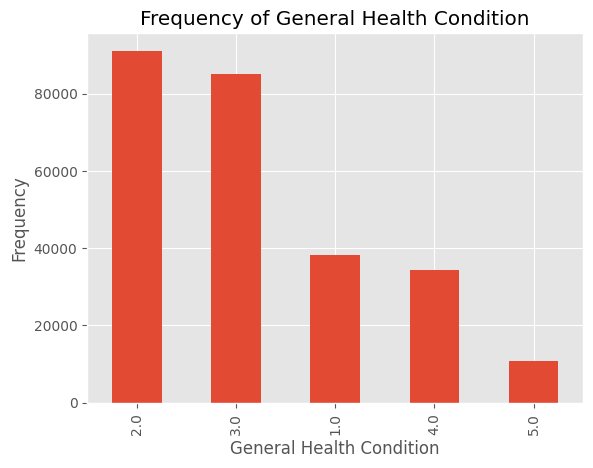

In [54]:
GenHlth_ax = df['GenHlth'].value_counts().plot(kind='bar', title='Frequency of General Health Condition')

GenHlth_ax.set_xlabel('General Health Condition')
GenHlth_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

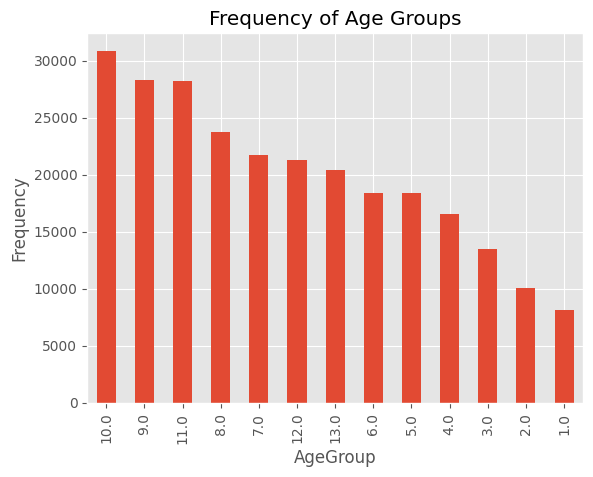

In [55]:
AgeGroup_ax = df['AgeGroup'].value_counts().plot(kind='bar', title='Frequency of Age Groups')

AgeGroup_ax.set_xlabel('AgeGroup')
AgeGroup_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

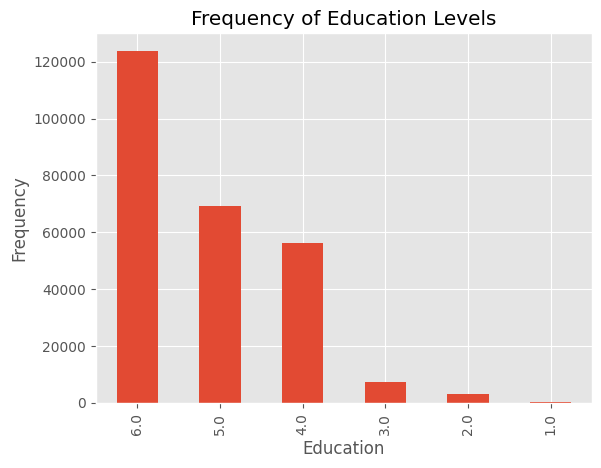

In [56]:
Education_ax = df['Education'].value_counts().plot(kind='bar', title='Frequency of Education Levels')

Education_ax.set_xlabel('Education')
Education_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

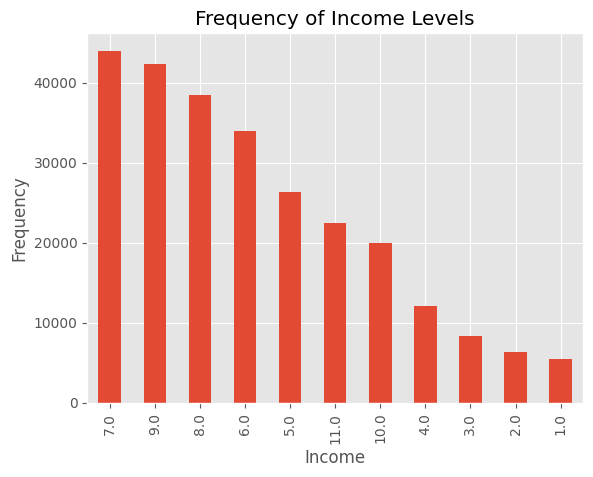

In [57]:
Income_ax = df['Income'].value_counts().plot(kind='bar', title='Frequency of Income Levels')

Income_ax.set_xlabel('Income')
Income_ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

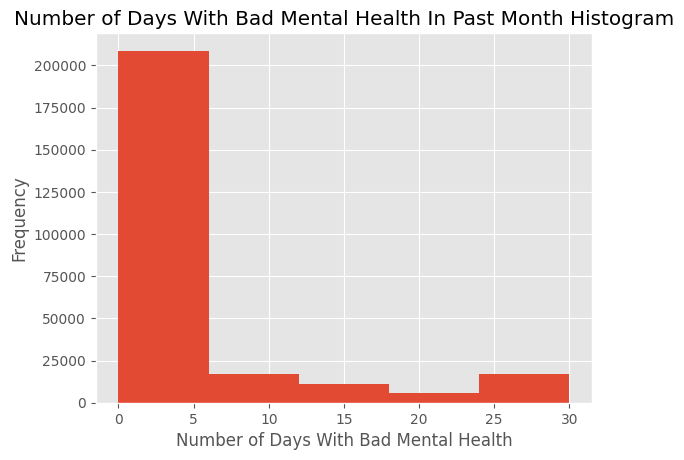

In [58]:
MentHlth_hist = df['MentHlth'].plot(kind='hist',title='Number of Days With Bad Mental Health In Past Month Histogram', bins=5)
MentHlth_hist.set_xlabel('Number of Days With Bad Mental Health')
MentHlth_hist.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

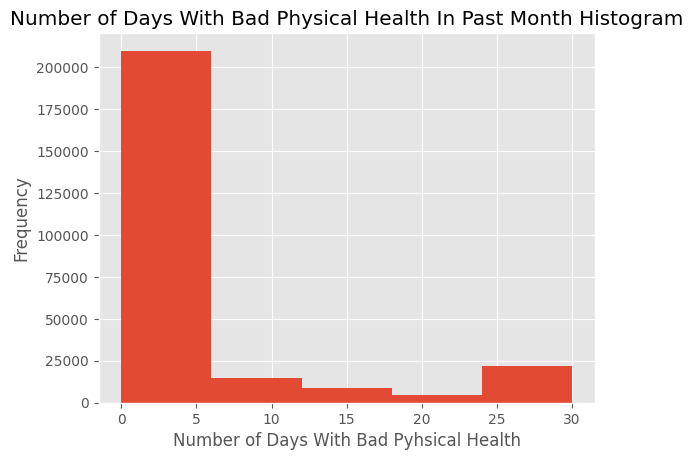

In [59]:
PhysHlth_hist = df['PhysHlth'].plot(kind='hist',title='Number of Days With Bad Physical Health In Past Month Histogram', bins=5)
PhysHlth_hist.set_xlabel('Number of Days With Bad Pyhsical Health')
PhysHlth_hist.set_ylabel('Frequency')

### Visualization for Real Valued (BMI)Feature 

Text(0.5, 0, 'Body Mass Index')

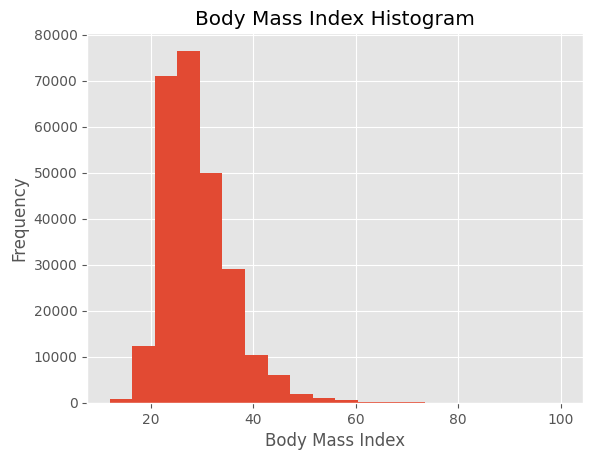

In [60]:
BMI_hist = df['BMI'].plot(kind='hist',title='Body Mass Index Histogram', bins=20)
BMI_hist.set_ylabel('Frequency')
BMI_hist.set_xlabel('Body Mass Index')


## Feature Relationships

### Income-Education Relation

<Axes: xlabel='Income', ylabel='count'>

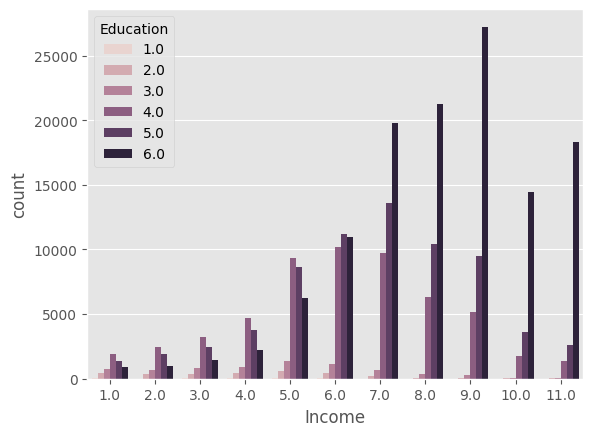

In [61]:
sns.countplot(data=df, x='Income', hue='Education')


In [62]:
spearman_corr = df[['Income','Education']].corr(method='spearman')
print(spearman_corr)

             Income  Education
Income     1.000000   0.430815
Education  0.430815   1.000000


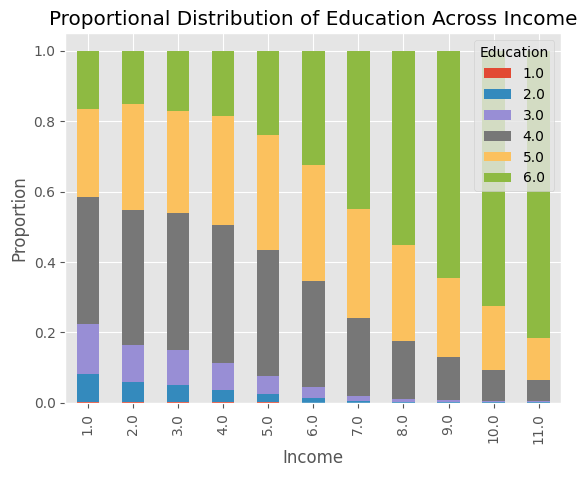

In [63]:
tab = pd.crosstab(df['Income'], df['Education'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Education Across Income')
plt.show()


### Income- AnyHealthcare

<Axes: xlabel='Income', ylabel='count'>

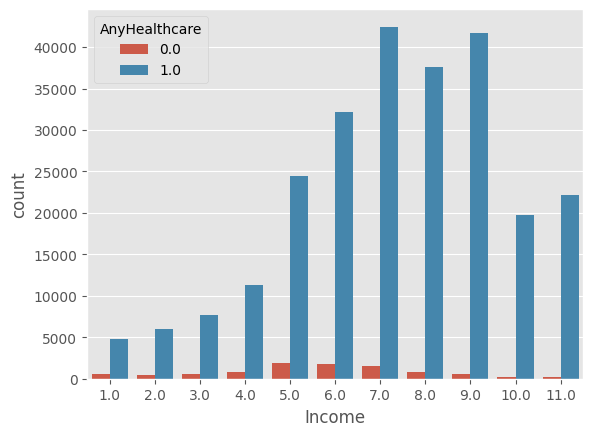

In [64]:
sns.countplot(data=df, x='Income', hue='AnyHealthcare')

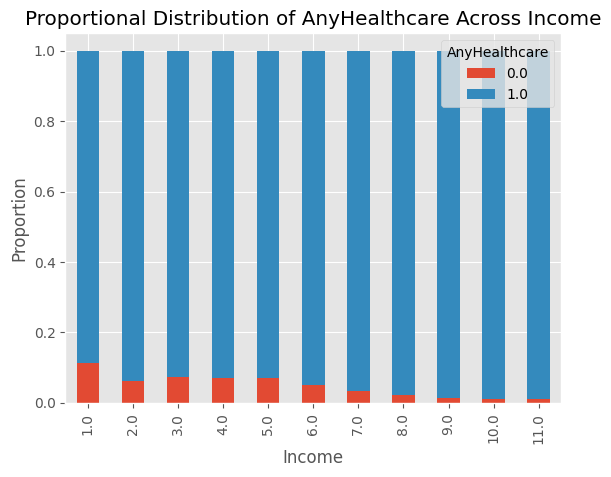

In [65]:
tab = pd.crosstab(df['Income'], df['AnyHealthcare'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of AnyHealthcare Across Income')
plt.show()

### Correlation among the Numerical Features

In [66]:
corr = df[['MentHlth','PhysHlth','BMI']].corr(method='pearson')
print(corr)

          MentHlth  PhysHlth       BMI
MentHlth  1.000000  0.325468  0.091073
PhysHlth  0.325468  1.000000  0.115177
BMI       0.091073  0.115177  1.000000


<Axes: >

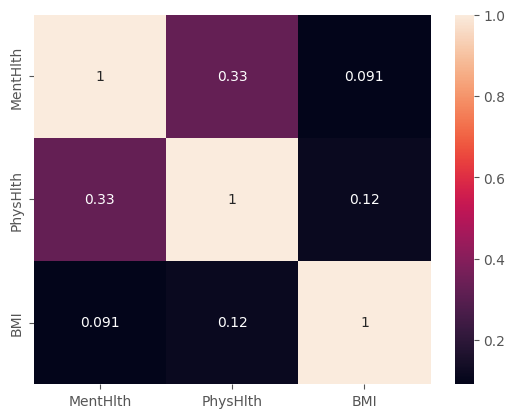

In [67]:
sns.heatmap(corr, annot=True)

### Nominal Features

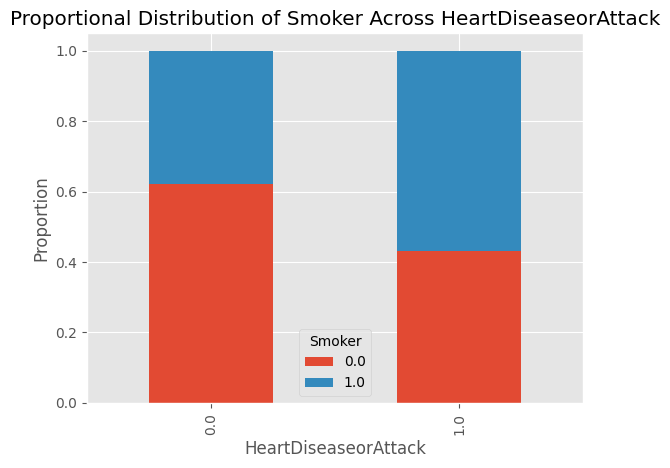

In [68]:
tab = pd.crosstab(df['HeartDiseaseorAttack'], df['Smoker'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Smoker Across HeartDiseaseorAttack')
plt.show()

<Axes: xlabel='HeartDiseaseorAttack', ylabel='count'>

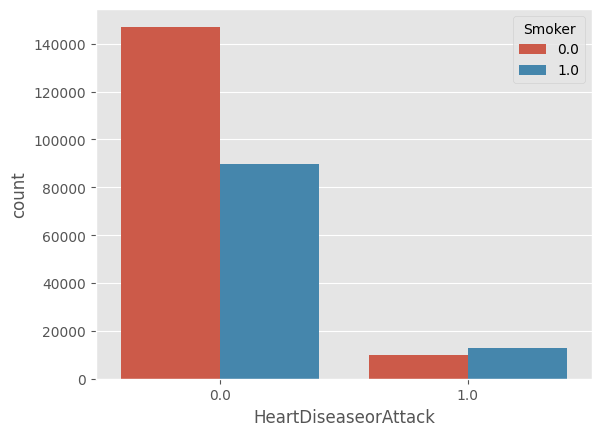

In [69]:
sns.countplot(data=df, x='HeartDiseaseorAttack', hue='Smoker')

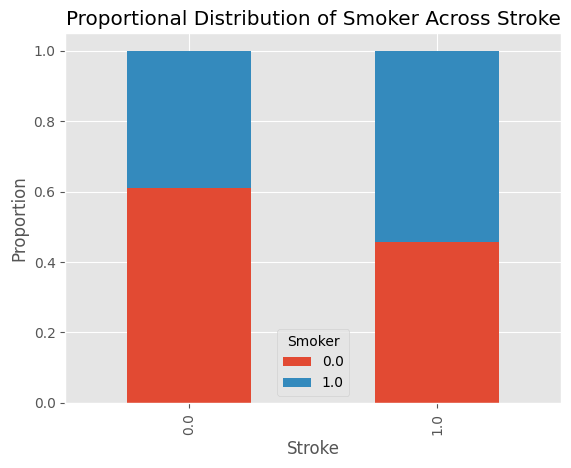

In [70]:
tab = pd.crosstab(df['Stroke'], df['Smoker'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Smoker Across Stroke')
plt.show()

<Axes: xlabel='Stroke', ylabel='count'>

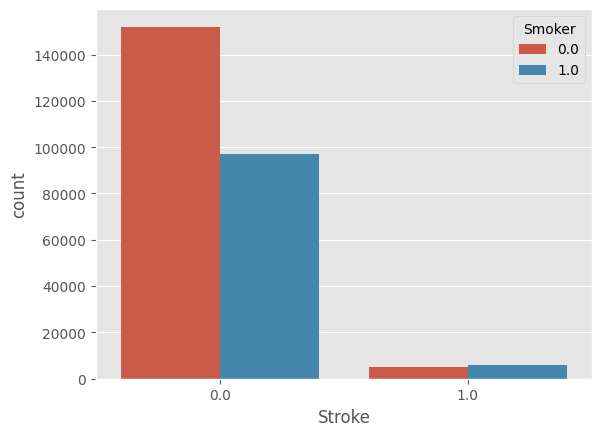

In [71]:
sns.countplot(data=df, x='Stroke', hue='Smoker')

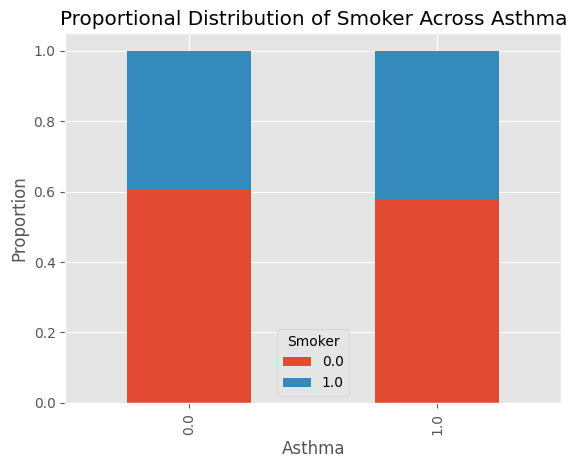

In [72]:
tab = pd.crosstab(df['Asthma'], df['Smoker'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Smoker Across Asthma')
plt.show()

<Axes: xlabel='Asthma', ylabel='count'>

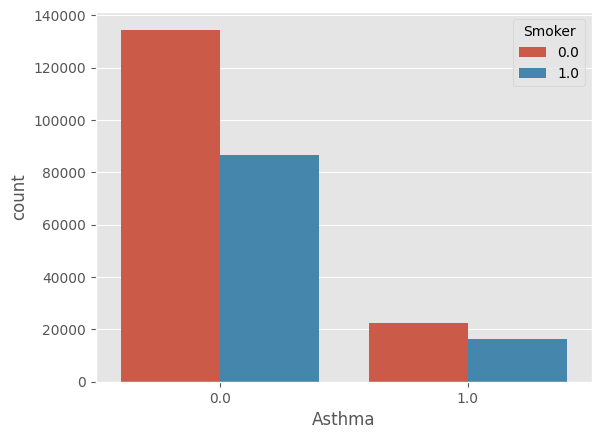

In [73]:
sns.countplot(data=df, x='Asthma', hue='Smoker')

## TARGET - FEATURE RELATIONS

### Target - Nominal Features Relations

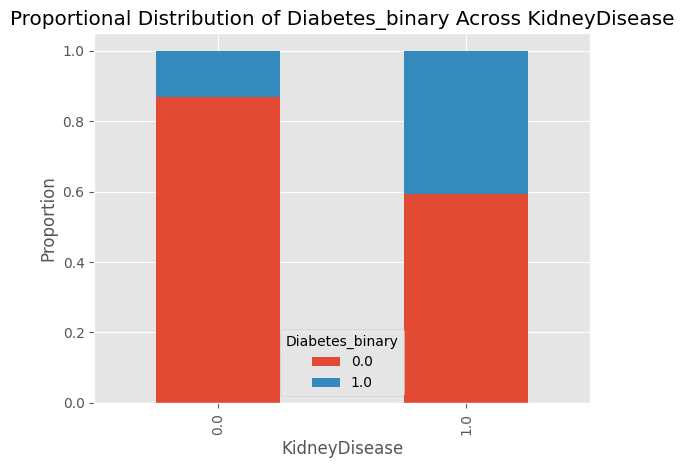

In [74]:
tab = pd.crosstab(df['KidneyDisease'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across KidneyDisease')
plt.show()

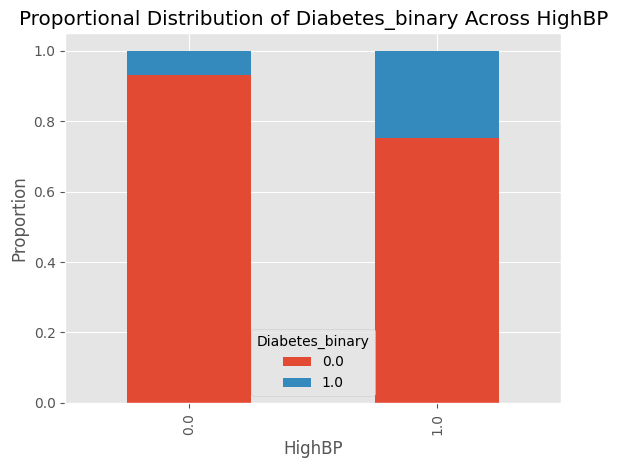

In [75]:
tab = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across HighBP')
plt.show()

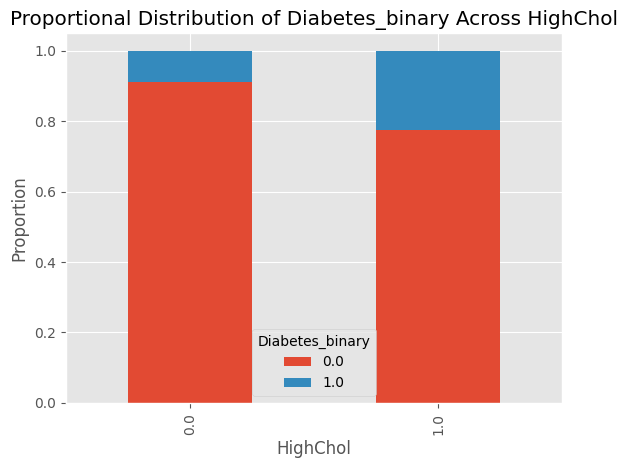

In [76]:
tab = pd.crosstab(df['HighChol'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across HighChol')
plt.show()

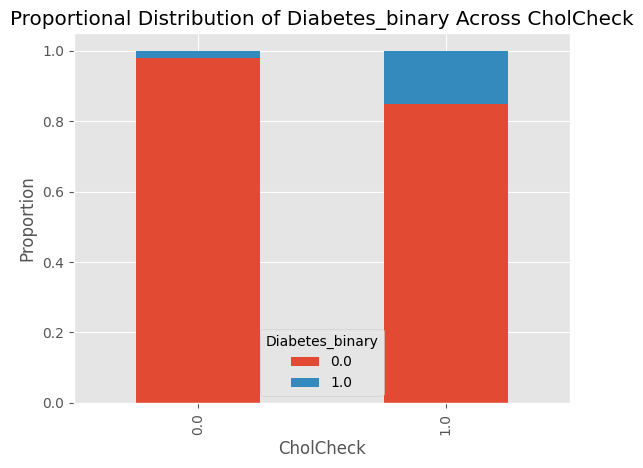

In [77]:
tab = pd.crosstab(df['CholCheck'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across CholCheck')
plt.show()

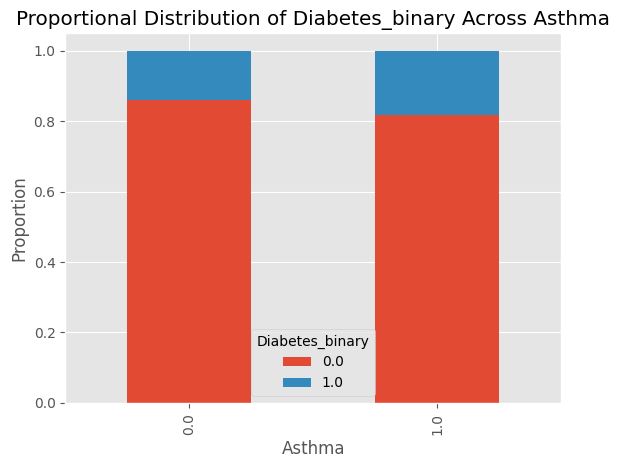

In [78]:
tab = pd.crosstab(df['Asthma'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Asthma')
plt.show()

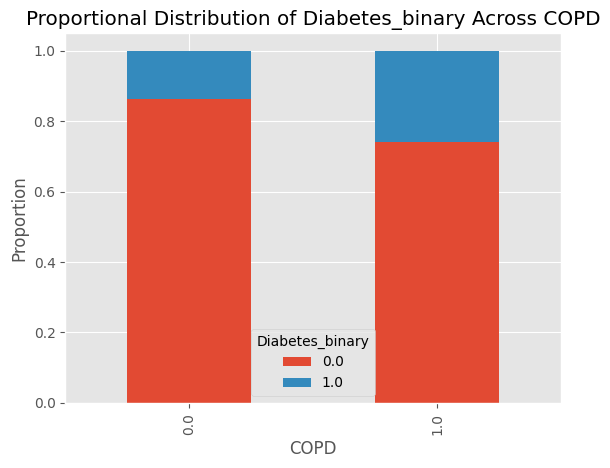

In [79]:
tab = pd.crosstab(df['COPD'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across COPD')
plt.show()

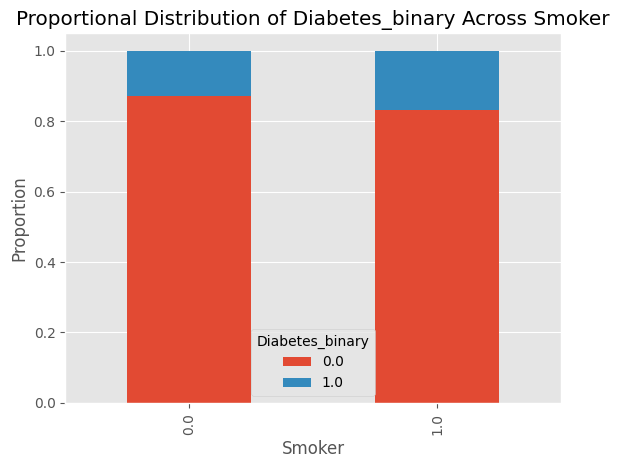

In [80]:
tab = pd.crosstab(df['Smoker'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Smoker')
plt.show()

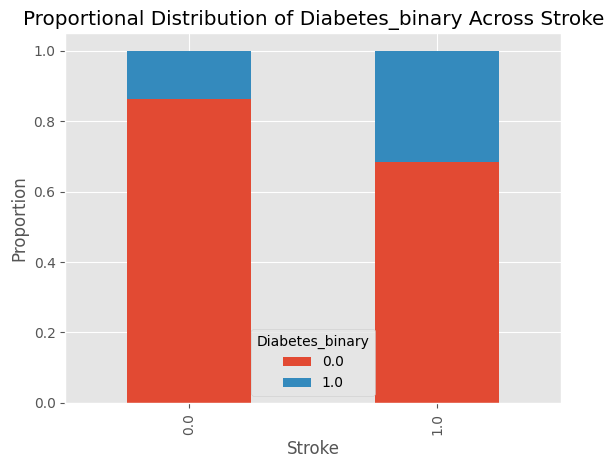

In [81]:
tab = pd.crosstab(df['Stroke'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Stroke')
plt.show()

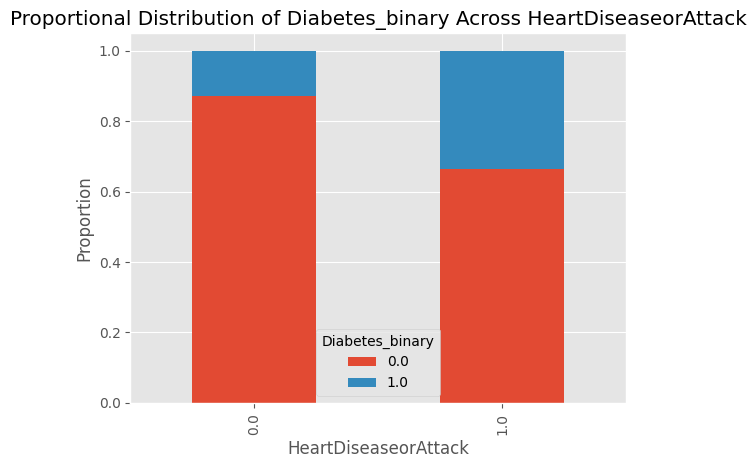

In [82]:
tab = pd.crosstab(df['HeartDiseaseorAttack'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across HeartDiseaseorAttack')
plt.show()

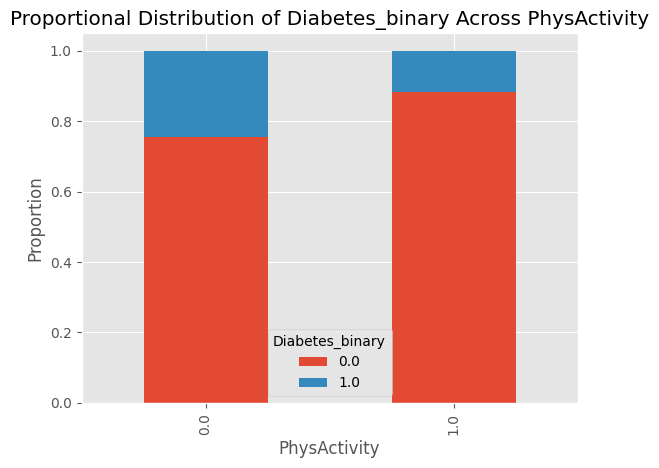

In [83]:
tab = pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across PhysActivity')
plt.show()

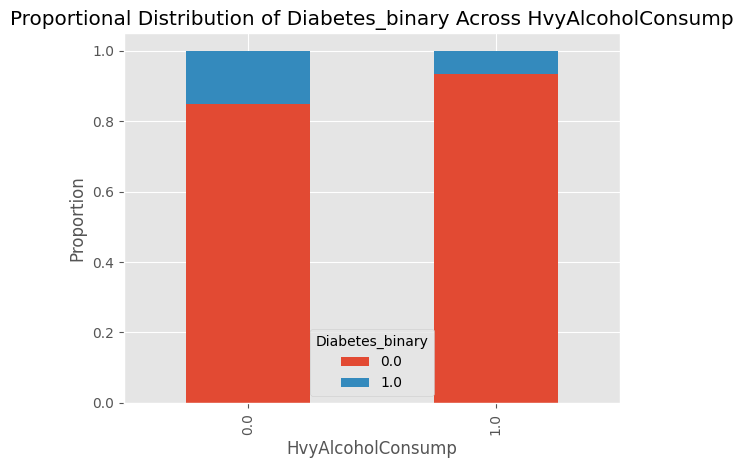

In [84]:
tab = pd.crosstab(df['HvyAlcoholConsump'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across HvyAlcoholConsump')
plt.show()

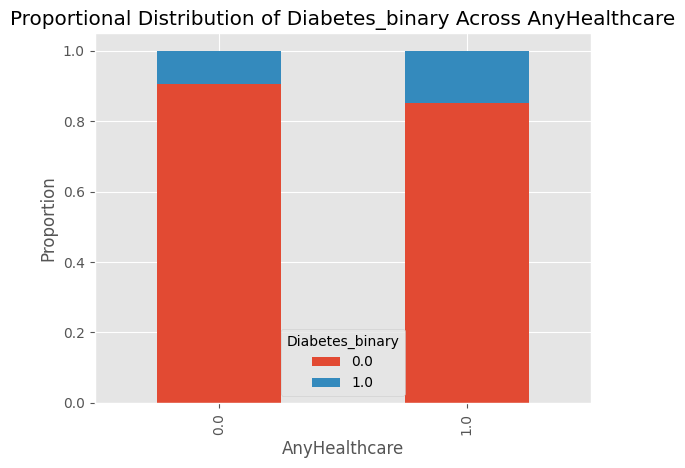

In [85]:
tab = pd.crosstab(df['AnyHealthcare'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across AnyHealthcare')
plt.show()

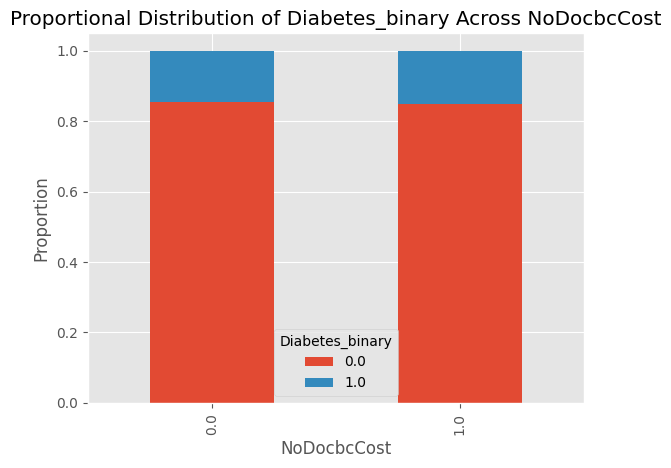

In [86]:
tab = pd.crosstab(df['NoDocbcCost'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across NoDocbcCost')
plt.show()

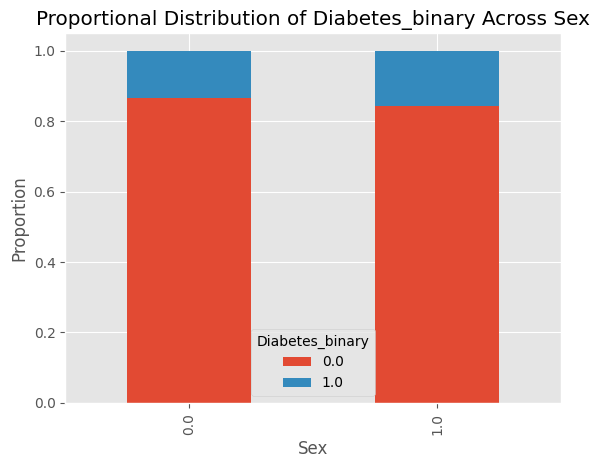

In [87]:
tab = pd.crosstab(df['Sex'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Sex')
plt.show()

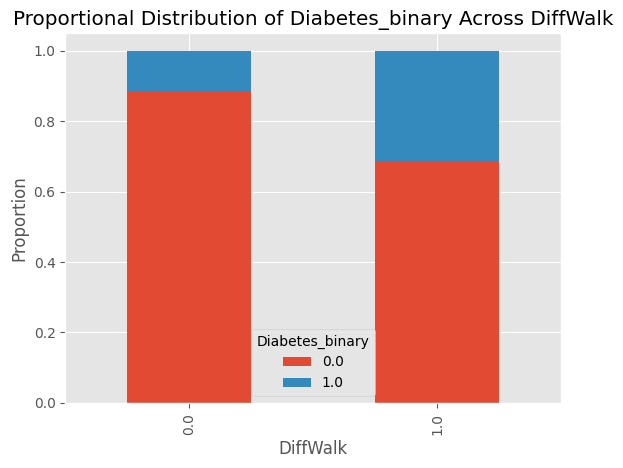

In [88]:
tab = pd.crosstab(df['DiffWalk'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across DiffWalk')
plt.show()

### Target - Ordinal Features Relations

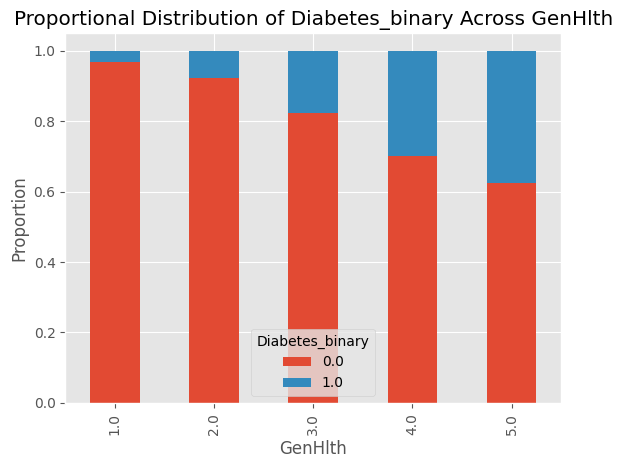

In [89]:
tab = pd.crosstab(df['GenHlth'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across GenHlth')
plt.show()

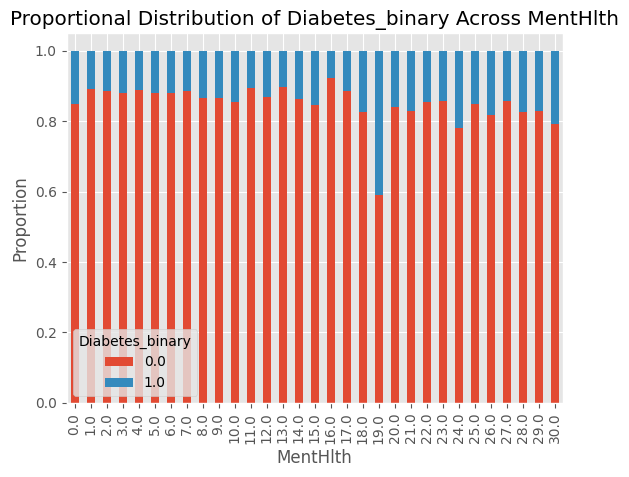

In [90]:
tab = pd.crosstab(df['MentHlth'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across MentHlth')
plt.show()

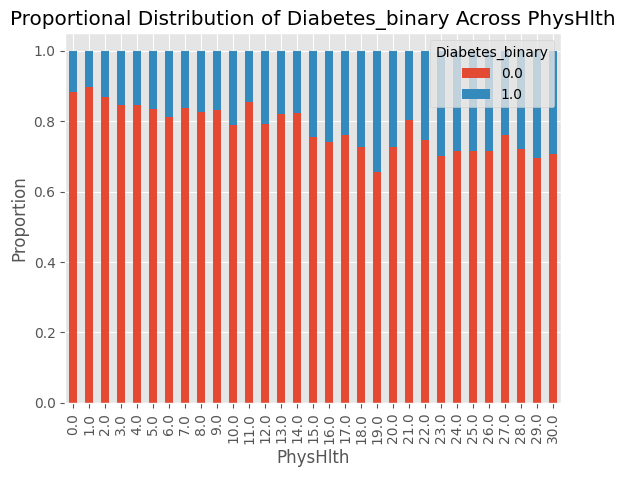

In [91]:
tab = pd.crosstab(df['PhysHlth'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across PhysHlth')
plt.show()

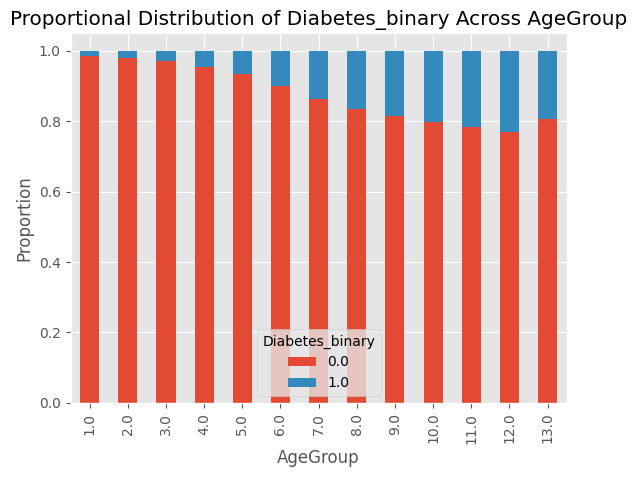

In [92]:
tab = pd.crosstab(df['AgeGroup'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across AgeGroup')
plt.show()

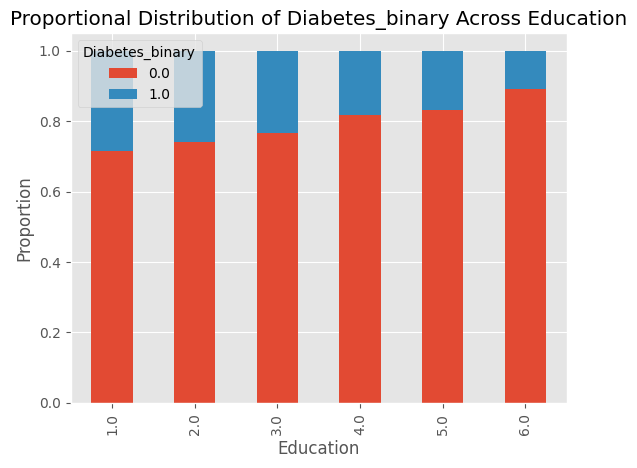

In [93]:
tab = pd.crosstab(df['Education'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Education')
plt.show()

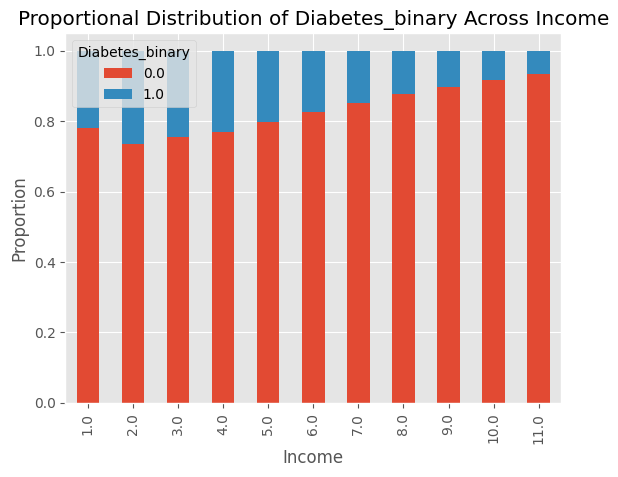

In [94]:
tab = pd.crosstab(df['Income'], df['Diabetes_binary'], normalize='index')
tab.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Proportional Distribution of Diabetes_binary Across Income')
plt.show()

### Diabates - BMI Relation

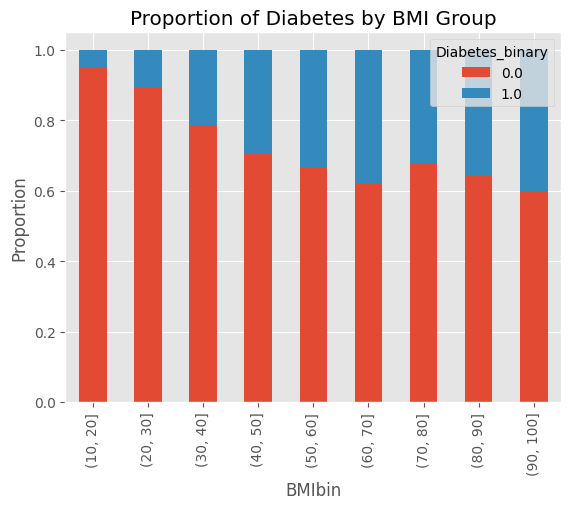

In [95]:
df_BMI = df[['Diabetes_binary','BMI']].copy()
df_BMI['BMIbin'] = pd.cut(df_BMI['BMI'], bins=list(range(0,101,10)))
BMI_tab = pd.crosstab(df_BMI['BMIbin'], df_BMI['Diabetes_binary'], normalize='index')
BMI_tab.plot(kind='bar', stacked=True)
plt.title('Proportion of Diabetes by BMI Group')
plt.ylabel('Proportion')
plt.show()